# Data Loading

In [1]:
import pandas as pd

url = "https://drive.google.com/uc?export=download&id=1NdUpKIZwv1uBIszx_8x53NaS1FE9nT_O"
df = pd.read_csv(url)

print(df.head())

        specialty  appointment_time gender no_show    disability  \
0   psychotherapy                17      F     yes  intellectual   
1             NaN                 7      M      no  intellectual   
2  speech therapy                16      M      no  intellectual   
3  speech therapy                14      M     yes  intellectual   
4   physiotherapy                 8      M      no         motor   

              place appointment_shift   age  under_12_years_old  \
0  Lake Marvinville         afternoon   9.0                   1   
1           ITAPEMA           morning  11.0                   1   
2            ITAJAÍ         afternoon   8.0                   1   
3         Sarahside         afternoon   9.0                   1   
4            ITAJAÍ           morning   NaN                   0   

   over_60_years_old  ...  storm_day_before  rain_intensity  heat_intensity  \
0                  0  ...                 1         no_rain            warm   
1                  0  ...     

In [2]:
df.shape

(109593, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13 

In [ ]:
df.isnull().sum()

,0
specialty,20127
appointment_time,0
gender,0
no_show,0
disability,16601
place,11539
appointment_shift,0
age,22960
under_12_years_old,0
over_60_years_old,0


In [ ]:
df.describe()

,appointment_time,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
count,109593.000000,86633.000000,109593.000000,109593.000000,109593.000000,107382.000000,107348.000000,107366.000000,107330.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000
mean,12.120966,18.632138,0.446424,0.071328,0.519823,20.346642,0.183537,24.032910,2.048093,0.937396,0.937533,0.058088,0.023952,0.018541,0.009116,0.055113,0.311808
std,3.281623,17.666999,0.497124,0.257372,0.499609,3.446079,0.416267,3.959696,4.352247,0.242251,0.242004,0.233910,0.152901,0.134899,0.095040,0.228202,0.463234
min,7.000000,2.000000,0.000000,0.000000,0.000000,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,8.000000,0.000000,0.000000,0.000000,18.060000,0.000000,21.400000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,12.000000,0.000000,0.000000,1.000000,20.600000,0.010000,23.900000,0.200000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,18.000000,1.000000,0.000000,1.000000,22.720000,0.150000,26.800000,1.900000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,18.000000,110.000000,1.000000,1.000000,1.000000,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df["no_show"].value_counts()

,count
no_show,
no,74761
yes,34832


# Data Cleaning and Missing Value Handling

In [3]:
df["age"] = df["age"].fillna(df["age"].median())
df["specialty"] = df["specialty"].fillna("Unknown")
df["disability"] = df["disability"].fillna("Unknown")
df["place"] = df["place"].fillna("Unknown")


In [4]:
weather_cols = [
    "average_temp_day",
    "average_rain_day",
    "max_temp_day",
    "max_rain_day"
]

for col in weather_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [5]:
df.isnull().sum()

,0
specialty,0
appointment_time,0
gender,0
no_show,0
disability,0
place,0
appointment_shift,0
age,0
under_12_years_old,0
over_60_years_old,0


In [6]:
df["appointment_date_continuous"] = pd.to_datetime(df["appointment_date_continuous"])

In [ ]:
df["appointment_date_continuous"].dtype

dtype('<M8[ns]')

# Feature engineering

In [7]:
df["year"] = df["appointment_date_continuous"].dt.year

df["month"] = df["appointment_date_continuous"].dt.month

df["day"] = df["appointment_date_continuous"].dt.day

df["weekday"] = df["appointment_date_continuous"].dt.dayofweek

df["week"] = (
    df["appointment_date_continuous"]
      .dt.isocalendar()
      .week
)

In [8]:
df["no_show"] = df["no_show"].map({
    "no": 0,
    "yes": 1
})

In [9]:
df["no_show"].value_counts()

,count
no_show,
0,74761
1,34832


# EDA (Exploratory Data Analysis)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

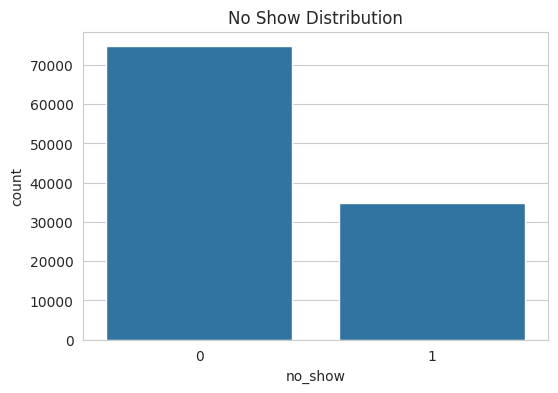

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='no_show', data=df)

plt.title("No Show Distribution")
plt.show()

In [13]:
df['no_show'].value_counts(normalize=True)*100

,proportion
no_show,
0,68.216948
1,31.783052


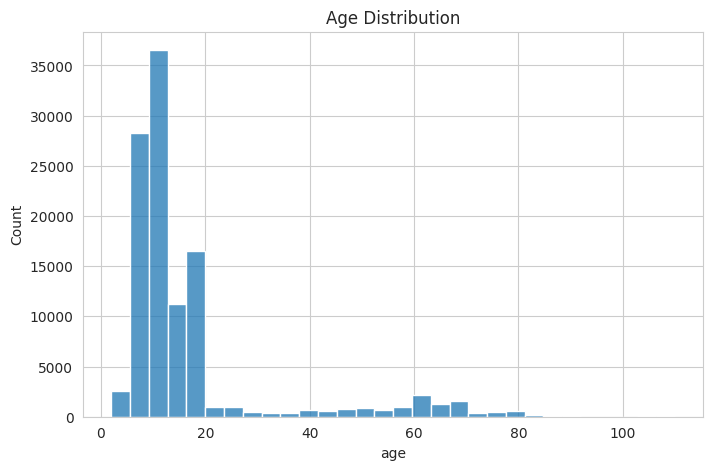

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")
plt.show()

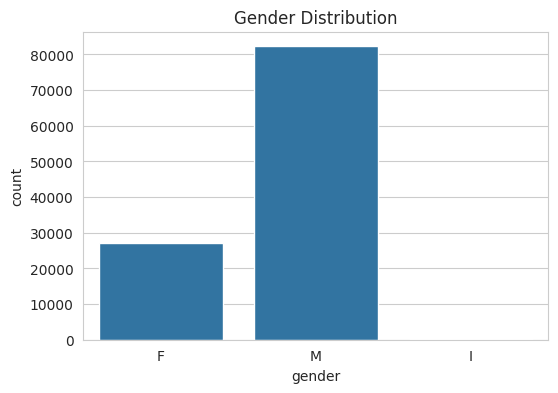

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.show()

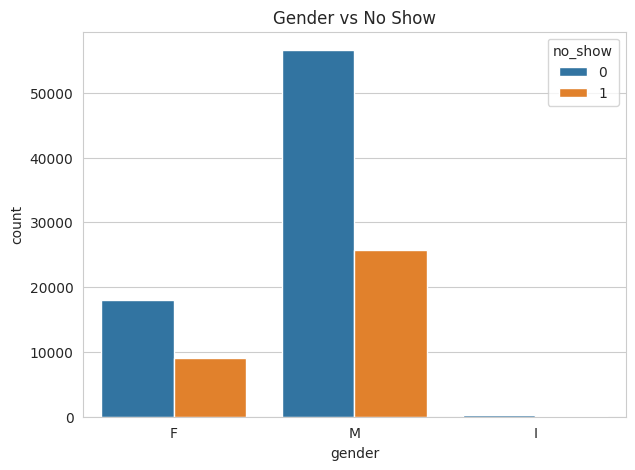

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='gender',
    hue='no_show',
    data=df
)

plt.title("Gender vs No Show")
plt.show()

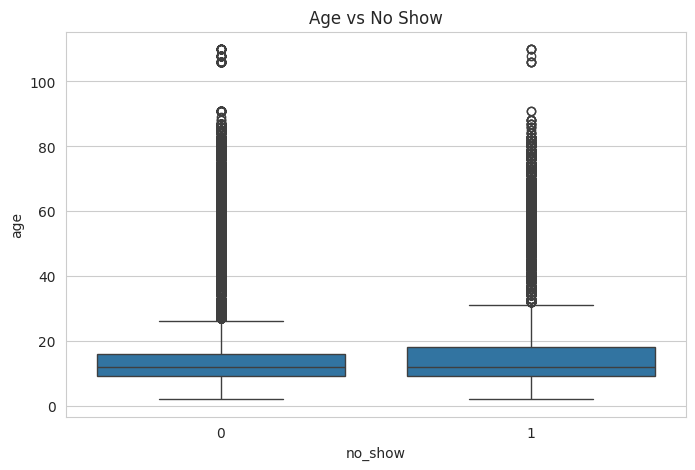

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='no_show',
    y='age',
    data=df
)

plt.title("Age vs No Show")
plt.show()

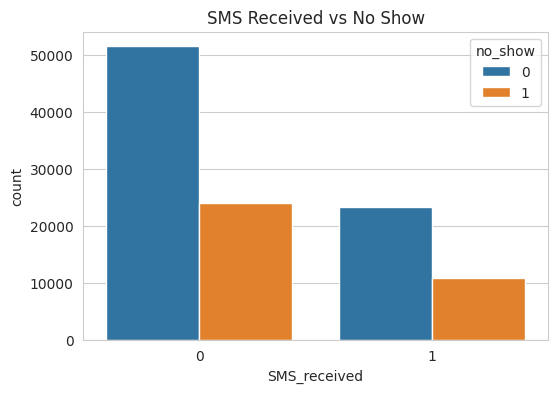

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='SMS_received',
    hue='no_show',
    data=df
)

plt.title("SMS Received vs No Show")
plt.show()

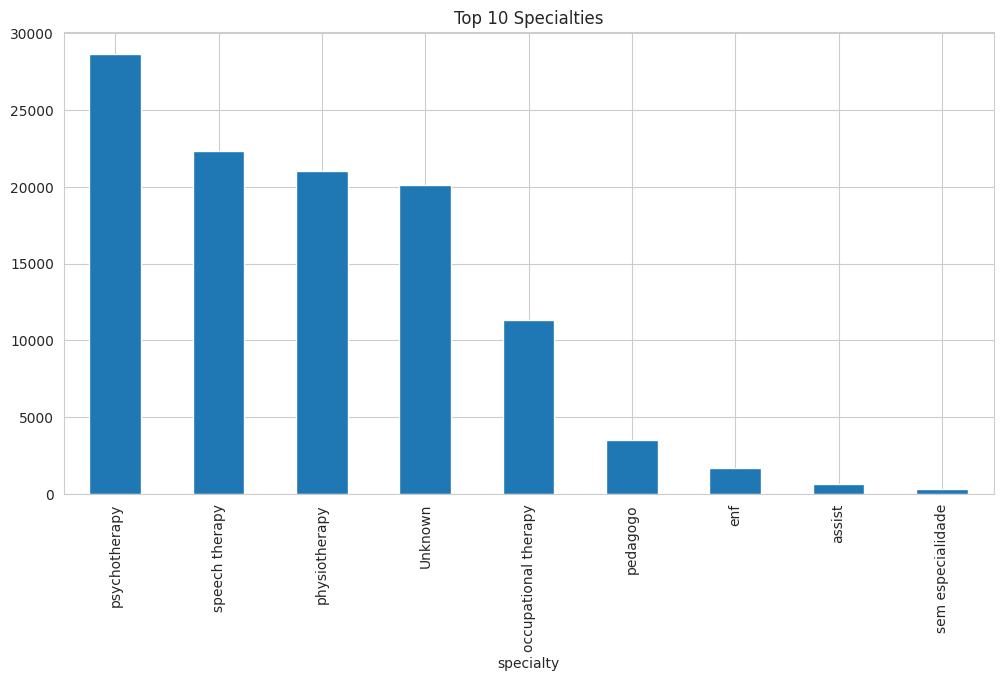

In [19]:
plt.figure(figsize=(12,6))

df['specialty'].value_counts()[:10].plot(
    kind='bar'
)

plt.title("Top 10 Specialties")
plt.show()

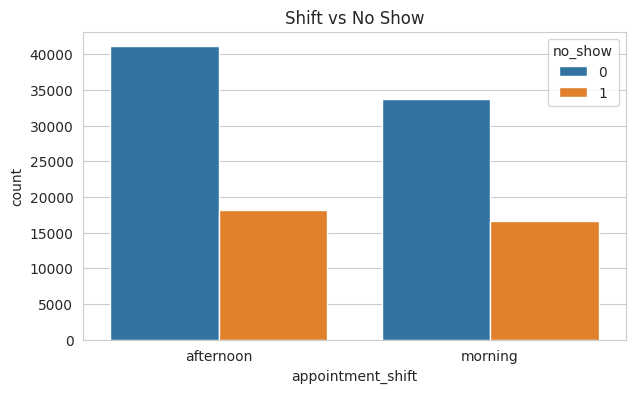

In [20]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='appointment_shift',
    hue='no_show',
    data=df
)

plt.title("Shift vs No Show")
plt.show()

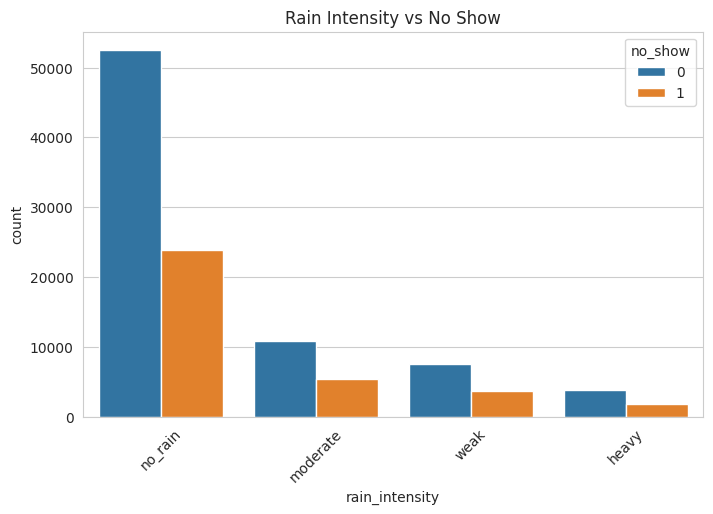

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rain_intensity',
    hue='no_show',
    data=df
)

plt.xticks(rotation=45)

plt.title("Rain Intensity vs No Show")
plt.show()

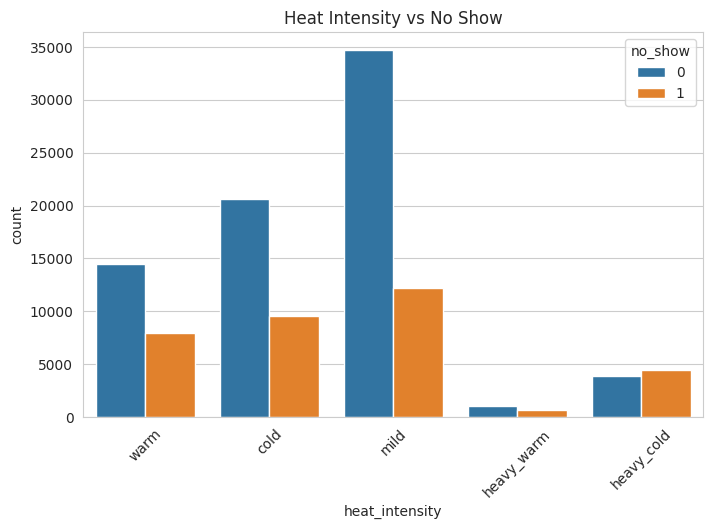

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='heat_intensity',
    hue='no_show',
    data=df
)

plt.xticks(rotation=45)

plt.title("Heat Intensity vs No Show")
plt.show()

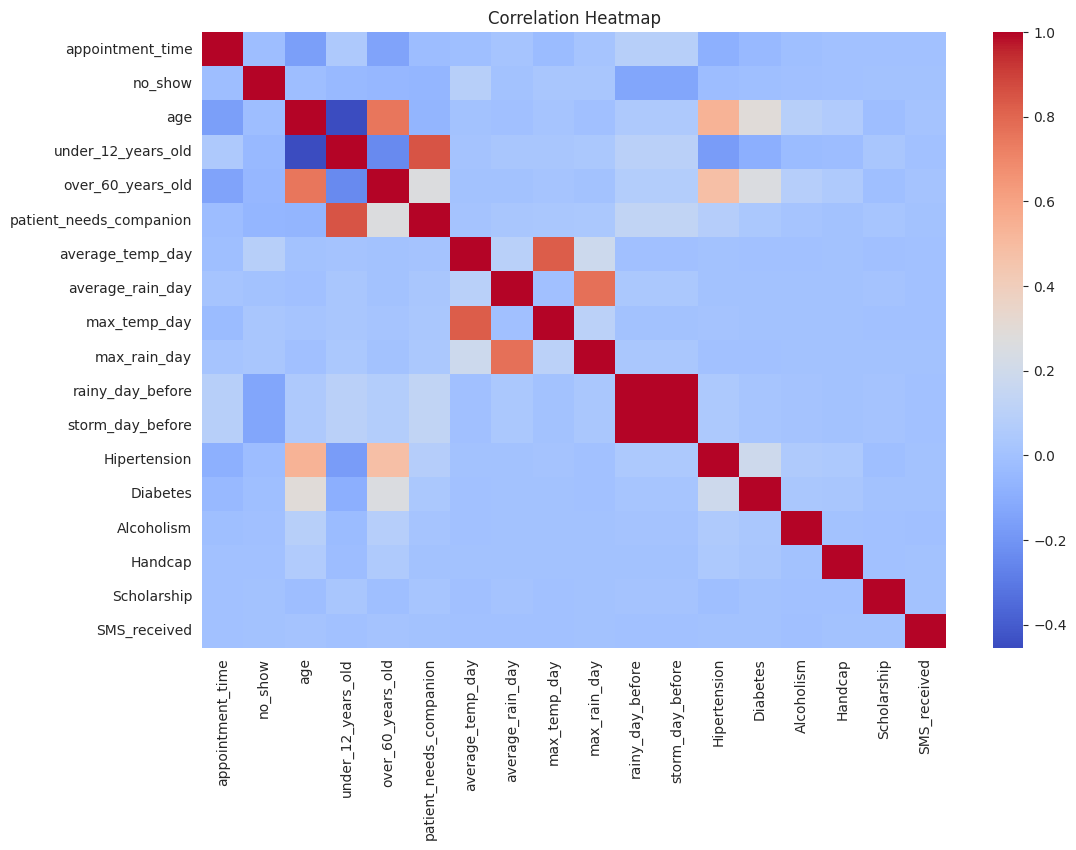

In [23]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(
    include=['int64','float64']
)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

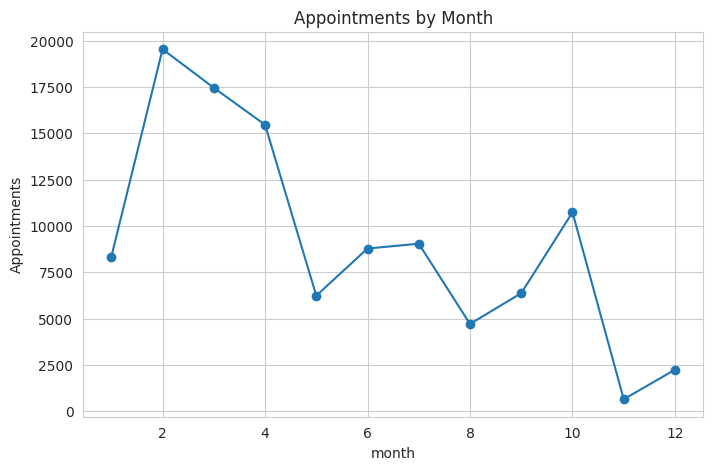

In [24]:
monthly = (
    df.groupby('month')
      .size()
)

monthly.plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title("Appointments by Month")
plt.ylabel("Appointments")
plt.show()

Observation:
Around 31.8% of appointments are missed.

Business Insight:
A high no-show rate can lead to wasted specialist
time and reduced clinic efficiency.

In [25]:
df_model = df.copy()

# Feature Engineering

In [26]:
df_model["month"] = df_model["appointment_date_continuous"].dt.month

df_model["day"] = df_model["appointment_date_continuous"].dt.day

df_model["weekday"] = df_model["appointment_date_continuous"].dt.dayofweek

In [27]:
df_model.drop(
    "appointment_date_continuous",
    axis=1,
    inplace=True
)

# training model

In [28]:
X = df_model.drop("no_show", axis=1)
y = df_model["no_show"]

In [29]:
y.value_counts()

,count
no_show,
0,74761
1,34832


In [30]:
X.select_dtypes(include="object").columns

Index(['specialty', 'gender', 'disability', 'place', 'appointment_shift',
       'rain_intensity', 'heat_intensity'],
      dtype='object')

In [31]:
cat_cols = [
    'specialty',
    'gender',
    'disability',
    'place',
    'appointment_shift',
    'rain_intensity',
    'heat_intensity'
]

In [32]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

In [33]:
df_model.shape

(109593, 30)

In [34]:
X = df_model.drop("no_show", axis=1)
y = df_model["no_show"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print(X_train.shape)
print(X_test.shape)

(87674, 29)
(21919, 29)


# For No-Show Prediction (Classification):


# 1.Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [39]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:,1]
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score
)
print(classification_report(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.78      0.66      0.71     14952
           1       0.45      0.60      0.51      6967

    accuracy                           0.64     21919
   macro avg       0.61      0.63      0.61     21919
weighted avg       0.67      0.64      0.65     21919

F1 Score: 0.5139740132385389
ROC AUC: 0.6619215219144783


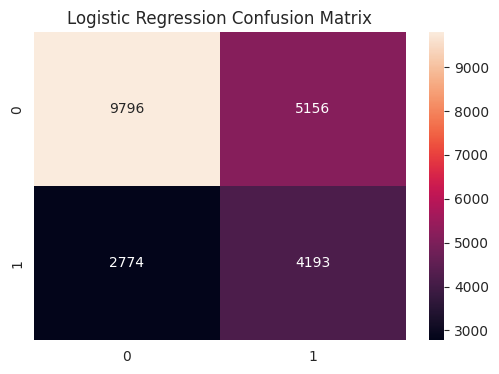

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 2.Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [42]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [44]:
# Recreate classification data
df_class = df.copy()

# Apply the same preprocessing you used

In [45]:
X_class = df_class.drop("no_show", axis=1)

print(X_class.columns.tolist())

['specialty', 'appointment_time', 'gender', 'disability', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'year', 'month', 'day', 'weekday', 'week']


In [46]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score

print(classification_report(y_test, rf_pred))

print("F1:", f1_score(y_test, rf_pred))
print("ROC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.85      0.69      0.76     14952
           1       0.52      0.73      0.61      6967

    accuracy                           0.70     21919
   macro avg       0.68      0.71      0.68     21919
weighted avg       0.74      0.70      0.71     21919

F1: 0.6100783071313288
ROC: 0.7716177390346587


In [47]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(scale_pos_weight)

2.146384353131168


# 3.xgboost

In [48]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.15,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [49]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:, 1]

In [50]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score
)

print(classification_report(y_test, xgb_pred))

print("F1:", f1_score(y_test, xgb_pred))
print("ROC:", roc_auc_score(y_test, xgb_prob))

              precision    recall  f1-score   support

           0       0.87      0.66      0.75     14952
           1       0.52      0.80      0.63      6967

    accuracy                           0.70     21919
   macro avg       0.70      0.73      0.69     21919
weighted avg       0.76      0.70      0.71     21919

F1: 0.6292923007297618
ROC: 0.782732201059754


XGBoost was selected as the final model because it achieved the highest ROC-AUC (0.783) and highest F1-score (0.629), demonstrating better discrimination between no-show and attended appointments.

In [ ]:
# import joblib

#joblib.dump(
#    xgb,
#    "no_show_xgb_model.pkl"
#)

['no_show_xgb_model.pkl']

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
15,storm_day_before,0.191055
4,place,0.186968
3,disability,0.071412
14,rainy_day_before,0.054961
8,over_60_years_old,0.042652
6,age,0.037896
13,max_rain_day,0.028716
10,average_temp_day,0.028111
9,patient_needs_companion,0.026667
17,heat_intensity,0.026397


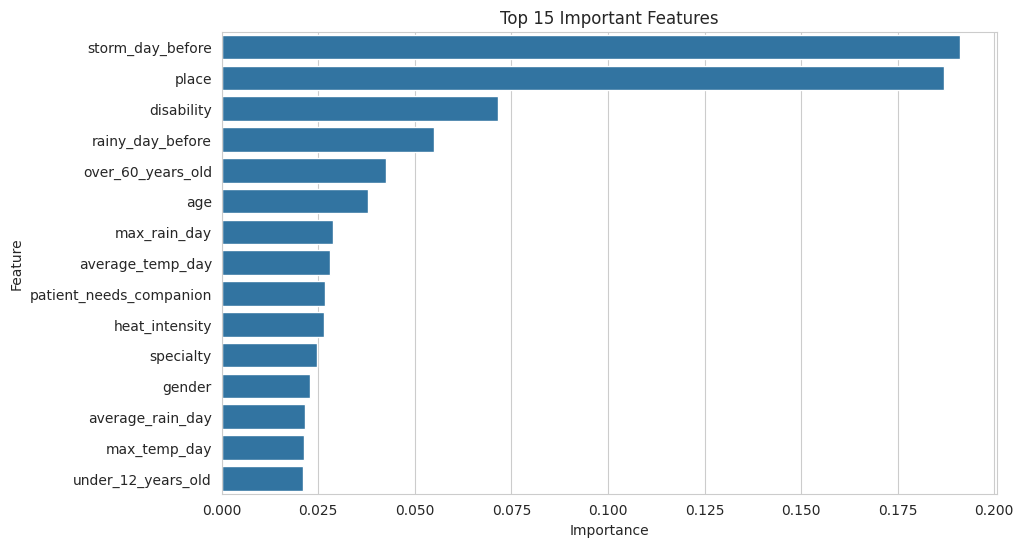

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

In [51]:
import pandas as pd

url = "https://drive.google.com/uc?export=download&id=1NdUpKIZwv1uBIszx_8x53NaS1FE9nT_O"

df = pd.read_csv(url)

print(df.head())

        specialty  appointment_time gender no_show    disability  \
0   psychotherapy                17      F     yes  intellectual   
1             NaN                 7      M      no  intellectual   
2  speech therapy                16      M      no  intellectual   
3  speech therapy                14      M     yes  intellectual   
4   physiotherapy                 8      M      no         motor   

              place appointment_shift   age  under_12_years_old  \
0  Lake Marvinville         afternoon   9.0                   1   
1           ITAPEMA           morning  11.0                   1   
2            ITAJAÍ         afternoon   8.0                   1   
3         Sarahside         afternoon   9.0                   1   
4            ITAJAÍ           morning   NaN                   0   

   over_60_years_old  ...  storm_day_before  rain_intensity  heat_intensity  \
0                  0  ...                 1         no_rain            warm   
1                  0  ...     

In [52]:
df["appointment_date_continuous"] = pd.to_datetime(
    df["appointment_date_continuous"]
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   specialty                    89466 non-null   object        
 1   appointment_time             109593 non-null  int64         
 2   gender                       109593 non-null  object        
 3   no_show                      109593 non-null  object        
 4   disability                   92992 non-null   object        
 5   place                        98054 non-null   object        
 6   appointment_shift            109593 non-null  object        
 7   age                          86633 non-null   float64       
 8   under_12_years_old           109593 non-null  int64         
 9   over_60_years_old            109593 non-null  int64         
 10  patient_needs_companion      109593 non-null  int64         
 11  average_temp_day          

In [53]:
print(df["appointment_date_continuous"].min())
print(df["appointment_date_continuous"].max())
print(df["appointment_date_continuous"].nunique())

2020-01-01 00:00:00
2021-05-12 00:00:00
498


In [54]:
daily = (
    df.groupby("appointment_date_continuous")
      .size()
      .reset_index(name="appointments")
)

daily.head()

,appointment_date_continuous,appointments
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


In [ ]:
daily.shape

(498, 2)

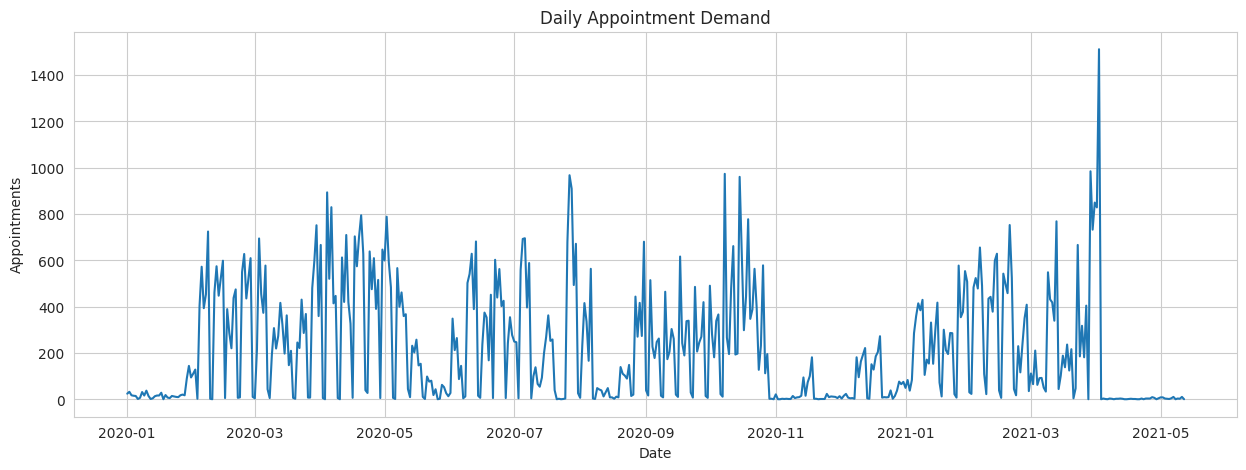

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    daily["appointment_date_continuous"],
    daily["appointments"]
)

plt.title("Daily Appointment Demand")
plt.xlabel("Date")
plt.ylabel("Appointments")
plt.show()

In [55]:
daily["dayofweek"] = daily[
    "appointment_date_continuous"
].dt.dayofweek

daily["month"] = daily[
    "appointment_date_continuous"
].dt.month

daily["quarter"] = daily[
    "appointment_date_continuous"
].dt.quarter

daily["day"] = daily[
    "appointment_date_continuous"
].dt.day

In [ ]:
daily.head()

,appointment_date_continuous,appointments,dayofweek,month,quarter,day
0,2020-01-01,25,2,1,1,1
1,2020-01-02,33,3,1,1,2
2,2020-01-03,18,4,1,1,3
3,2020-01-04,16,5,1,1,4
4,2020-01-05,15,6,1,1,5


In [56]:
daily["lag_1"] = daily["appointments"].shift(1)
daily["lag_7"] = daily["appointments"].shift(7)
daily["lag_14"] = daily["appointments"].shift(14)

In [57]:
daily["rolling_mean_7"] = (
    daily["appointments"]
    .rolling(7)
    .mean()
)

daily["rolling_mean_14"] = (
    daily["appointments"]
    .rolling(14)
    .mean()
)

In [58]:
daily = daily.dropna()
daily.shape


(484, 11)

In [59]:
X = daily.drop(
    ["appointment_date_continuous", "appointments"],
    axis=1
)

y = daily["appointments"]

In [60]:
split = int(len(daily) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [61]:
print(X_train.shape)
print(X_test.shape)

(387, 9)
(97, 9)


# For Demand Forecasting (Regression)

# 1.RandomForest

In [62]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [63]:
pred = rf_reg.predict(X_test)

In [64]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(
    mean_squared_error(y_test, pred)
)

r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 135.45742268041238
RMSE: 230.5648152269087
R2  : 0.34027676589587064


# 2.Linear Regression (Baseline)

In [65]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()

lr_reg.fit(X_train, y_train)

pred_lr = lr_reg.predict(X_test)

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

MAE : 161.46176610462618
RMSE: 241.1634086379854
R2  : 0.2782304777802799


# 3.XGBoost Regressor

In [67]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

pred_xgb = xgb_reg.predict(X_test)

In [68]:
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

MAE : 150.1885528564453
RMSE: 245.02986106289168
R2  : 0.25490134954452515


In [69]:
mae_rf = 135.457
rmse_rf = 230.565
r2_rf = 0.340

In [70]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,      # use your RF value
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,161.461766,241.163409,0.278230
1,Random Forest,135.457000,230.565000,0.340000
2,XGBoost,150.188553,245.029861,0.254901


Random Forest Regressor is the final forecasting model.low MAE,low RMSE,high R2

Three classification models were evaluated for no-show prediction. XGBoost achieved the best performance with an F1-score of 0.629 and ROC-AUC of 0.783, making it the selected classification model.

For demand forecasting, Linear Regression, Random Forest Regressor, and XGBoost Regressor were compared. Random Forest Regressor produced the lowest forecasting error (MAE = 135.46, RMSE = 230.57) and the highest R² score (0.34), and was selected as the final forecasting model.

The results indicate that patient attendance can be predicted with reasonable accuracy and that historical appointment patterns provide useful information for forecasting future demand.

In [ ]:
# from google.colab import files
# import joblib

# # 1. Save the models to the cloud drive
# joblib.dump(xgb, "no_show_xgb_model.pkl")
# joblib.dump(rf_reg, "demand_forecast_rf.pkl")

# # 2. Download them to your local computer
# files.download("no_show_xgb_model.pkl")
# files.download("demand_forecast_rf.pkl")

In [ ]:
# forecast_features = [
#     'dayofweek',
#     'month',
#     'quarter',
#     'day',
#     'lag_1',
#     'lag_7',
#     'lag_14',
#     'rolling_mean_7',
#     'rolling_mean_14'
# ]

# joblib.dump(
#     forecast_features,
#     "forecast_features.pkl"
# )

['forecast_features.pkl']

In [ ]:
# from google.colab import files


# files.download("forecast_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# classification_features = X.columns.tolist()

# joblib.dump(
#     classification_features,
#     "classification_features.pkl"
# )


['classification_features.pkl']

In [ ]:
#files.download("classification_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>